In [47]:

from google.colab import files
uploaded = files.upload()

!unzip "archive (7).zip"

Saving archive (7).zip to archive (7) (5).zip
Archive:  archive (7).zip
replace brain_tumor_dataset/no/1 no.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: All
  inflating: brain_tumor_dataset/no/1 no.jpeg  
  inflating: brain_tumor_dataset/no/10 no.jpg  
  inflating: brain_tumor_dataset/no/11 no.jpg  
  inflating: brain_tumor_dataset/no/12 no.jpg  
  inflating: brain_tumor_dataset/no/13 no.jpg  
  inflating: brain_tumor_dataset/no/14 no.jpg  
  inflating: brain_tumor_dataset/no/15 no.jpg  
  inflating: brain_tumor_dataset/no/17 no.jpg  
  inflating: brain_tumor_dataset/no/18 no.jpg  
  inflating: brain_tumor_dataset/no/19 no.jpg  
  inflating: brain_tumor_dataset/no/2 no.jpeg  
  inflating: brain_tumor_dataset/no/20 no.jpg  
  inflating: brain_tumor_dataset/no/21 no.jpg  
  inflating: brain_tumor_dataset/no/22 no.jpg  
  inflating: brain_tumor_dataset/no/23 no.jpg  
  inflating: brain_tumor_dataset/no/24 no.jpg  
  inflating: brain_tumor_dataset/no/25 no.jpg  
  inflating: brain_tumor_dat

In [56]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [57]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "brain_tumor_dataset",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "brain_tumor_dataset",
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [58]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(1,activation='sigmoid'))

In [59]:
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [52]:

history = model.fit(
train_data,
epochs=10,
validation_data=val_data
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 948ms/step - accuracy: 0.6749 - loss: 0.6184 - val_accuracy: 0.7400 - val_loss: 0.5329
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8030 - loss: 0.5075 - val_accuracy: 0.7400 - val_loss: 0.5558
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 889ms/step - accuracy: 0.7980 - loss: 0.4725 - val_accuracy: 0.6800 - val_loss: 0.5484
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7931 - loss: 0.4544 - val_accuracy: 0.7600 - val_loss: 0.5357
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8276 - loss: 0.4202 - val_accuracy: 0.7600 - val_loss: 0.5144
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8424 - loss: 0.3770 - val_accuracy: 0.7600 - val_loss: 0.4995
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 993ms/step - accuracy: 0.8522 - loss: 0.3387 - val_accuracy: 0.8000 - val_loss: 0.5571
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8768 - loss: 0.2943 - val_accuracy: 0.8000 - val_loss: 0.4520
Epoch 9

In [53]:
loss, acc = model.evaluate(val_data)

print("Validation Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8000 - loss: 0.5191
Validation Accuracy: 0.800000011920929


In [54]:
img, label = next(val_data)

prediction = model.predict(img)

print("Predicted:", prediction[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
Predicted: [0.9891596]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

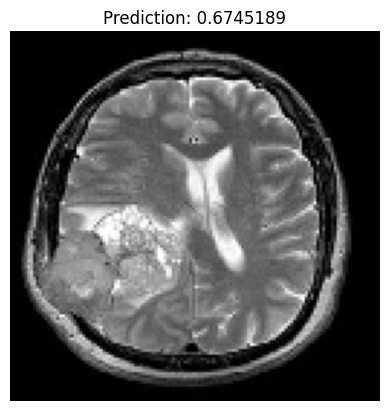

In [55]:
img, label = next(val_data)

prediction = model.predict(img)

plt.imshow(img[0])
plt.title("Prediction: " + str(prediction[0][0]))
plt.axis("off")